In [20]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [21]:
from save_read_results import build_result_table
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

%matplotlib widget

In [22]:
F,var = build_result_table(path="../data/results/frame_potential")

In [23]:
# get F and the var in a pandas dataframe
df = pd.DataFrame(F, columns=var)

# change the type of the var column to int
df["n_parameters"] = df["n_parameters"].astype(int)
df["circuit_depth"] = df["circuit_depth"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["frame_potential"] = df["frame_potential"].astype(float)
df["fidelity_error"] = df["fidelity_error"].astype(float)
df = df[df["n_qubits"] == 8]

df_SU4 = df[df["name"] == 'perfectSU4' ]
df_SU4_composed = df[df["name"] == 'perfectSU4_composed' ]

df = df[df["name"].str.contains("set") ]
# split the name column to get the number of the ansat and change it to int
df["name"] = df["name"].apply(lambda x: x.split("_")[1])
df["name"] = df["name"].astype(int)

df_SU4["name"] = 30
df_SU4_composed["name"] = 31

df = pd.concat([df, df_SU4, df_SU4_composed], ignore_index=True)

df['t'] = df['t'].astype(int)

df.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
0,31,256,1.9977490901947021,xpu,torch.complex64,0.057980,3.997749,2.0,64,8,512,13,1.998874545097351,2,2,881.249755859375
1,6,256,10026.1484375,xpu,torch.complex64,2582.551452,10032.148438,6.0,39,8,768,7,1672.0247395833333,1,3,3933873635328.0
2,9,256,253.81796264648438,xpu,torch.complex64,4.937642,254.817963,1.0,8,8,256,10,254.81796264648438,1,1,1597788.0
3,73,256,0.5601615905761719,xpu,torch.complex64,0.025716,2.560162,2.0,93,8,512,19,1.280080795288086,4,2,173.3532257080078
4,21,256,0.36631011962890625,xpu,torch.complex64,0.021294,2.366310,2.0,64,8,512,2,1.1831550598144531,4,2,118.86157989501953


In [24]:
long_CNOT = [5,6,10,13,14,15]
# remove the long CNOT from the dataframe
df = df[~df["name"].isin(long_CNOT)]

In [25]:
df_t1 = df[df["t"] == 1]
fp_objectif = 1
df_t1["frame_potential"] = abs(df_t1["frame_potential"] - fp_objectif + df_t1["fidelity_error"])
df_t2 = df[df["t"] == 2]
fp_objectif = 2
df_t2["frame_potential"] = abs(df_t2["frame_potential"] - fp_objectif + df_t2["fidelity_error"])
df_t3 = df[df["t"] == 3]
fp_objectif = 6
df_t3["frame_potential"] = abs(df_t3["frame_potential"] - fp_objectif + df_t3["fidelity_error"])
df_t1.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
5,18,256,0.005869865417480469,xpu,torch.complex64,0.005235,0.011105,1.0,80,8,256,11,1.0058698654174805,3,1,1.7957862615585327
7,2,256,0.00040602684020996094,xpu,torch.complex64,0.125766,0.126172,1.0,16,8,256,1,1.00040602684021,1,1,1036.5892333984375
9,6,256,0.11217021942138672,xpu,torch.complex64,0.081810,0.193980,1.0,48,8,256,1,1.1121702194213867,3,1,438.62158203125
18,30,256,-0.006581425666809082,xpu,torch.complex64,0.005873,0.000709,1.0,117,8,256,7,0.9934185743331909,5,1,2.260235548019409
20,30,256,8.463859558105469e-06,xpu,torch.complex64,0.004176,0.004185,1.0,132,8,256,11,1.000008463859558,5,1,1.1430418491363525


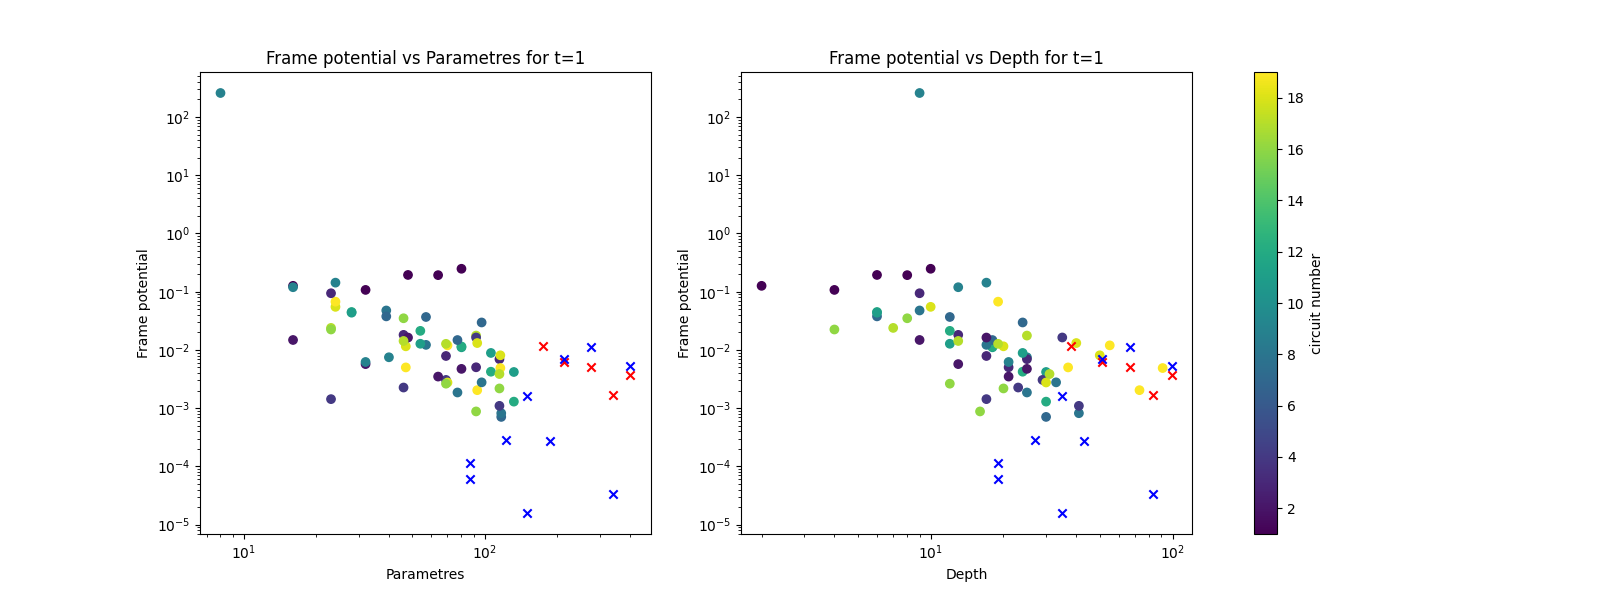

In [35]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t1[df_t1["name"] < 30]
df_highlight_1 = df_t1[df_t1["name"] == 30]
df_highlight_2 = df_t1[df_t1["name"] == 31]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
# give a red colo to the perfect_SU4 ansatz and a marker "x"
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    row = df_to_plot.iloc[i]
    sel.annotation.set_text(
    f"name={row['name']}\n"
    f"n_qubits={row['n_qubits']}\n"
    f"depth={row['circuit_depth']}\n"
    f"n_params={row['n_parameters']}\n"
    f"fp={row['frame_potential']:.3e}"
    )

plt.show()

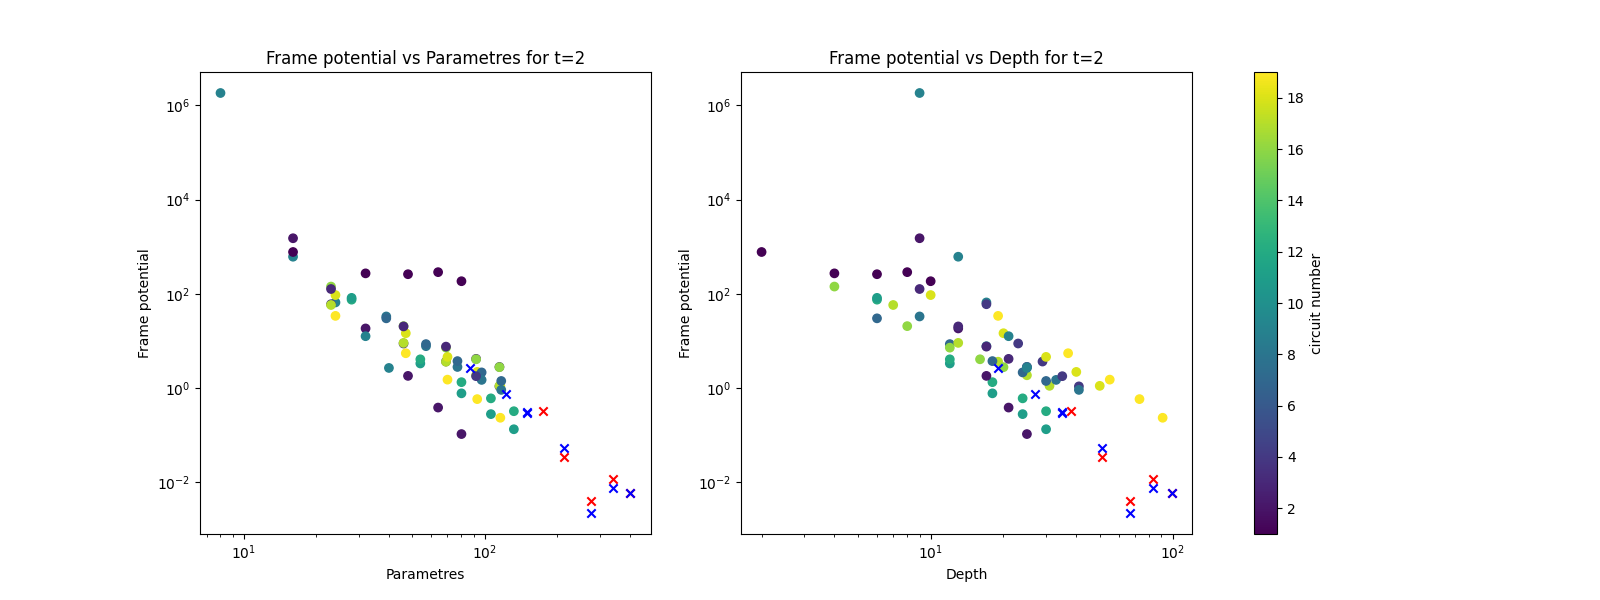

In [36]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t2[df_t2["name"] < 30]
df_highlight_1 = df_t2[df_t2["name"] == 30]
df_highlight_2 = df_t2[df_t2["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=2")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=2")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])


cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    row = df_to_plot.iloc[i]
    sel.annotation.set_text(
    f"name={row['name']}\n"
    f"n_qubits={row['n_qubits']}\n"
    f"depth={row['circuit_depth']}\n"
    f"n_params={row['n_parameters']}\n"
    f"fp={row['frame_potential']:.3e}\n"
    f"fidelity_error={row['fidelity_error']:.3e}"
    )

plt.show()

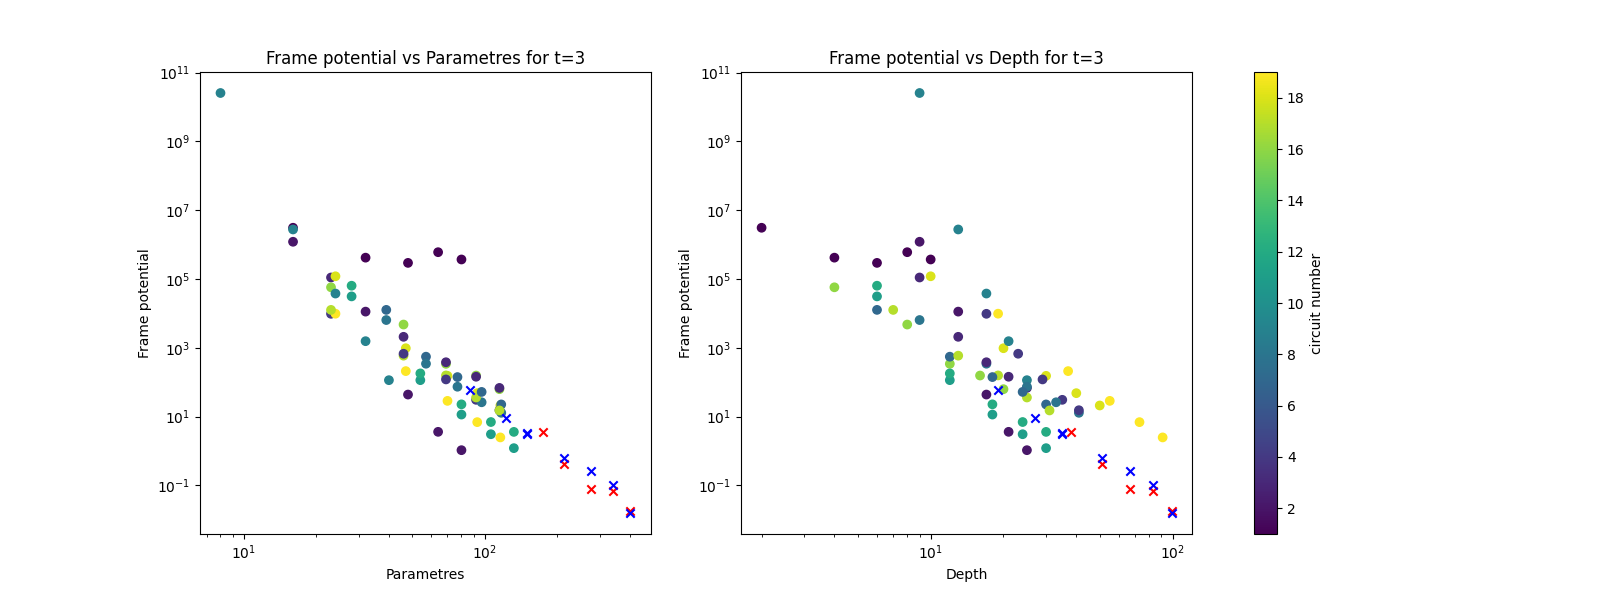

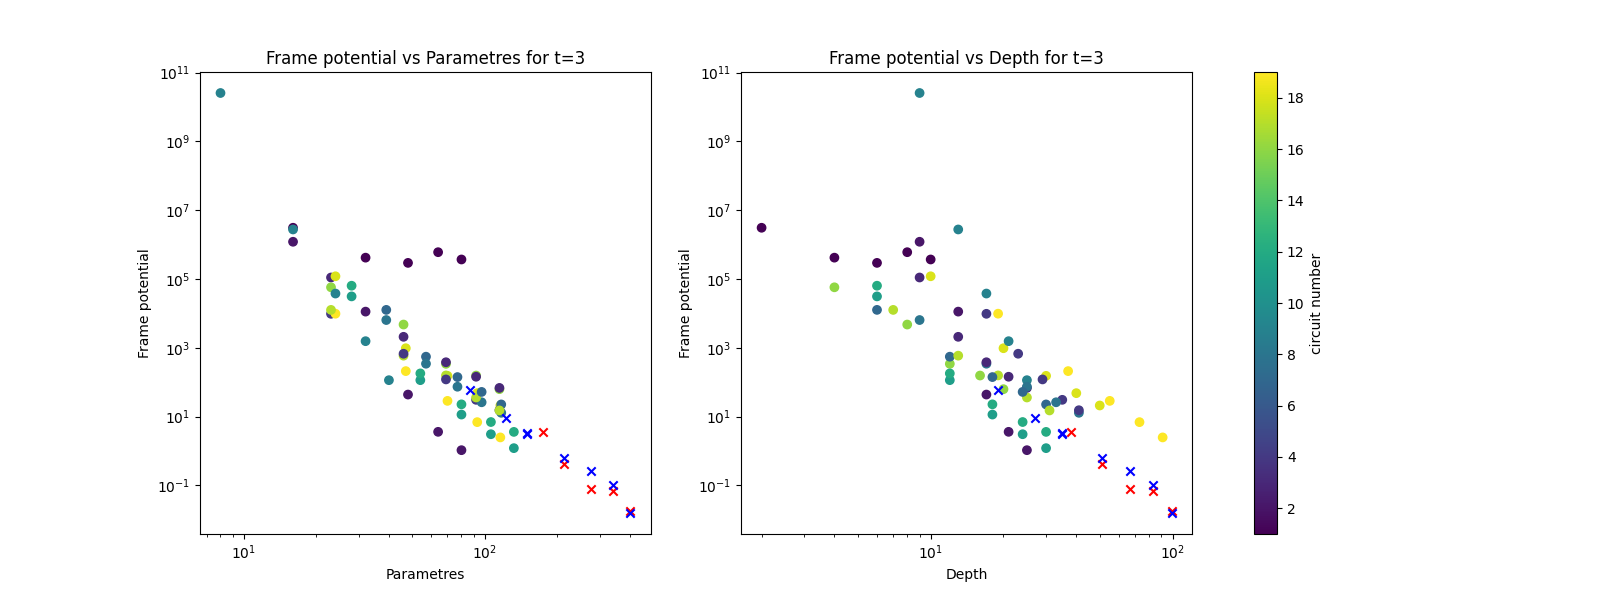

In [37]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t3[df_t3["name"] < 30]
df_highlight_1 = df_t3[df_t3["name"] == 30]
df_highlight_2 = df_t3[df_t3["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=3")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["frame_potential"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=3")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    row = df_to_plot.iloc[i]
    sel.annotation.set_text(
    f"name={row['name']}\n"
    f"n_qubits={row['n_qubits']}\n"
    f"depth={row['circuit_depth']}\n"
    f"n_params={row['n_parameters']}\n"
    f"fp={row['frame_potential']:.3e}\n"
    f"fidelity_error={row['fidelity_error']:.3e}"
    )

plt.show()

plt.show()

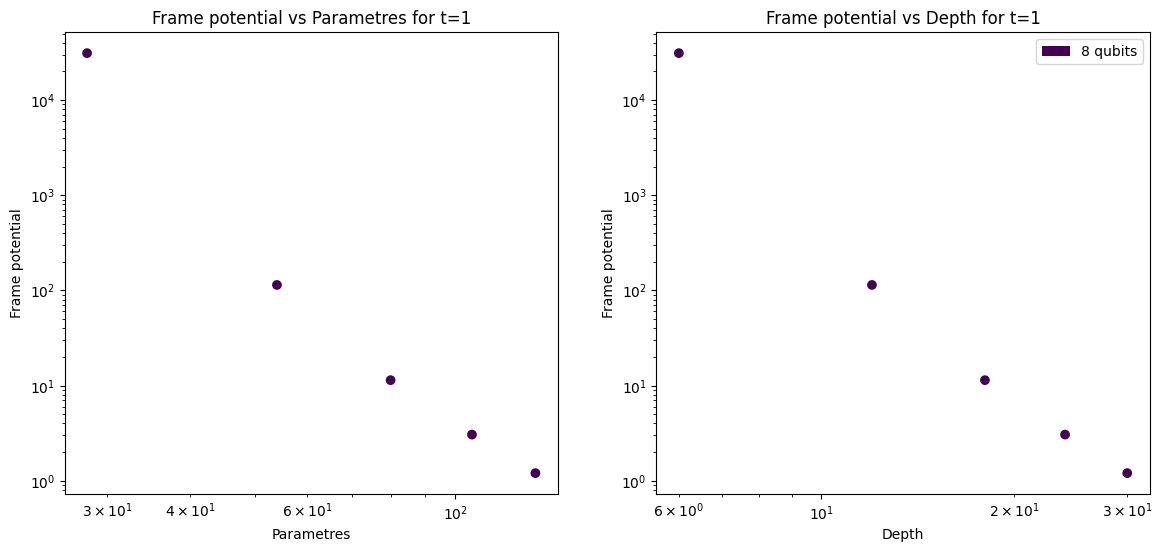

In [ ]:



df_to_plot = df_t3[df_t3["name"] == 11]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")

unique_vals = sorted(df_to_plot["n_qubits"].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_vals)))
legend_elements = [Patch(facecolor=colors[i], label=f"{int(val)} qubits") 
                   for i, val in enumerate(unique_vals)]
ax2.legend(handles=legend_elements, loc='best')
plt.show()